# FinSight: Exploratory Data Analysis & Preprocessing
Notebook ini mencakup langkah-langkah EDA, preprocessing (penanganan outlier), pemetaan MCC untuk mendapatkan kategori detail, serta implementasi NLP untuk klasifikasi transaksi ambigu (Transfer P2P).

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Load Data

In [4]:
df_transaksi = pd.read_csv('Data/df_transaksi.csv')
df_nasabah = pd.read_csv('Data/df_nasabah.csv')
df_transaksi['timestamp'] = pd.to_datetime(df_transaksi['timestamp'])
print("Shape Transaksi:", df_transaksi.shape)
print("Shape Nasabah:", df_nasabah.shape)

Shape Transaksi: (150274, 14)
Shape Nasabah: (500, 11)


## 1.2 Penyesuaian data

In [5]:
# Ekstrak komponen waktu yang dibutuhkan terlebih dahulu
df_transaksi['bulan'] = df_transaksi['timestamp'].dt.month
df_transaksi['hari_minggu'] = df_transaksi['timestamp'].dt.dayofweek
df_transaksi['jam'] = df_transaksi['timestamp'].dt.hour
df_transaksi['menit'] = df_transaksi['timestamp'].dt.minute
df_transaksi['hari_bulan'] = df_transaksi['timestamp'].dt.day

# --- Feature Engineering: Cyclical Time (Trigonometric Normalization) ---
df_transaksi['hour_sin'] = np.sin(2 * np.pi * df_transaksi['jam'] / 24)
df_transaksi['hour_cos'] = np.cos(2 * np.pi * df_transaksi['jam'] / 24)
df_transaksi['month_sin'] = np.sin(2 * np.pi * (df_transaksi['bulan']-1) / 12)
df_transaksi['month_cos'] = np.cos(2 * np.pi * (df_transaksi['bulan']-1) / 12)

# Pastikan data terurut berdasarkan waktu
df_transaksi = df_transaksi.sort_values(by=['id_user', 'timestamp'])

## 2. MCC Mapping
Melakukan pemetaan kategori detail berdasarkan file referensi `mcc_mapping.csv`.

In [6]:
# Muat file referensi mapping
mcc_mapping_ref = pd.read_csv('data/mcc_mapping.csv')

# Lakukan pemetaan ke dataframe utama
df_transaksi = df_transaksi.merge(mcc_mapping_ref, on=['mcc', 'deskripsi_mutasi'], how='left', suffixes=('', '_new'))

# Update kolom kategori_detail jika ditemukan di mapping baru
if 'kategori_detail_new' in df_transaksi.columns:
    df_transaksi['kategori_detail'] = df_transaksi['kategori_detail_new'].fillna(df_transaksi.get('kategori_detail', np.nan))
    df_transaksi.drop(columns=['kategori_detail_new'], inplace=True)

# KHUSUS MCC 4829: Otomatis set ke Transfer P2P (karena deskripsi mutasi dinamis)
df_transaksi.loc[df_transaksi['mcc'] == 4829, 'kategori_detail'] = 'Transfer P2P'

print("Pemetaan MCC selesai.")
display(df_transaksi[['mcc', 'deskripsi_mutasi', 'kategori_detail']].head(5))

Pemetaan MCC selesai.


,mcc,deskripsi_mutasi,kategori_detail
0,0,TRF MASUK - PENDAPATAN TETAP,Pendapatan Bulanan
1,5812,PIZZA HUT,F&B dan Nongkrong
2,5814,JAJANAN GEROBAK,F&B dan Nongkrong
3,4899,NETFLIX,Hiburan & Langganan
4,8099,BPJS KESEHATAN,Kesehatan & Perawatan Diri


### Validasi Hasil Mapping
Mengecek akurasi pemetaan sistem dibandingkan dengan Ground Truth.

In [8]:
# 1. Hitung Persentase Mapping
mapped_count = df_transaksi['kategori_detail'].notna().sum()
total_count = len(df_transaksi)
percent_mapped = (mapped_count / total_count) * 100

print(f"Total Data: {total_count}")
print(f"Data Ter-map: {mapped_count}")
print(f"Mapping Success Rate: {percent_mapped:.2f}%")

# 2. Perbandingan dengan Ground Truth (gt_kategori_detail)
# Cari baris di mana kategori_detail tidak sama dengan gt_kategori_detail
mismatch = df_transaksi[df_transaksi['kategori_detail'] != df_transaksi['gt_kategori_detail']]
mismatch_count = len(mismatch)

print(f"\nMismatch dengan Ground Truth: {mismatch_count} baris")

if mismatch_count > 0:
    print("\nSampel Mismatch (Top 10):")
    display(mismatch[['mcc', 'deskripsi_mutasi', 'kategori_detail', 'gt_kategori_detail']].head(10))
else:
    print("\nSelamat! Semua kategori detail sistem sudah sesuai dengan Ground Truth.")

Total Data: 150274
Data Ter-map: 150274
Mapping Success Rate: 100.00%

Mismatch dengan Ground Truth: 6158 baris

Sampel Mismatch (Top 10):


,mcc,deskripsi_mutasi,kategori_detail,gt_kategori_detail
0,0,TRF MASUK - PENDAPATAN TETAP,Pendapatan Bulanan,NaN
12,4829,TRF KE WARSA PANGESTU,Transfer P2P,Belanja Online & Fashion
13,4829,TRF KE HUMAIRA PRADIPTA,Transfer P2P,F&B dan Nongkrong
66,4829,TRF KE ULI YOLANDA,Transfer P2P,Tagihan & Utilitas
97,4829,TRF KE PUTI FEBI SIMANJUNTAK,Transfer P2P,Hiburan & Langganan
104,0,TRF MASUK - PENDAPATAN TETAP,Pendapatan Bulanan,NaN
155,0,TRF MASUK - PROFIT TRADING,Pemasukan,NaN
159,5977,WATSONS/GUARDIAN,Groceries & Kebutuhan Pokok,Kesehatan & Perawatan Diri
160,0,TRF MASUK - PENDAPATAN TETAP,Pendapatan Bulanan,NaN
182,5977,WATSONS/GUARDIAN,Groceries & Kebutuhan Pokok,Kesehatan & Perawatan Diri


## 3. Preprocessing (Outlier Handling)
Menghapus nilai tak masuk akal (nominal <= 0) dan melakukan *Winsorization* pada persentil 99 per MCC untuk menormalkan price markup yang ekstrem.

In [9]:
# Hapus nilai tidak valid
df_transaksi = df_transaksi[df_transaksi['nominal'] > 0].copy()

# Winsorize (Cap 99th percentile per MCC)
df_transaksi_clean = df_transaksi.copy()
for mcc in df_transaksi_clean['mcc'].unique():
    mask = df_transaksi_clean['mcc'] == mcc
    p99 = df_transaksi_clean.loc[mask, 'nominal'].quantile(0.99)
    if pd.notna(p99):
        df_transaksi_clean.loc[mask, 'nominal'] = df_transaksi_clean.loc[mask, 'nominal'].clip(upper=p99)

print("Preprocessing selesai.")

### --- PEMETAAN MCC / DETAIL KE BESAR ---
category_map = {
    'Transportasi': 'Needs',
    'Tagihan & Utilitas': 'Needs',
    'Kesehatan & Perawatan Diri': 'Needs',
    'Groceries & Kebutuhan Pokok': 'Needs',
    'Belanja Online & Fashion': 'Wants',
    'Produktivitas & Digital': 'Wants',
    'F&B dan Nongkrong': 'Wants',
    'Hiburan & Langganan': 'Wants',
    # 'Investasi & Finansial': 'Savings',  # Tabungan
    'Pendapatan Bulanan': 'Income',
    'Pemasukan Tambahan': 'Income',
    'Transfer P2P': 'Wants' # Default sebelum ditimpa NLP
}

# Terapkan pemetaan ke seluruh kolom
df_transaksi_clean['kategori_besar'] = df_transaksi_clean['kategori_detail'].map(category_map)

mask_ambiguous = df_transaksi_clean['kategori_detail'] == 'Transfer P2P'
df_ambiguous = df_transaksi_clean[mask_ambiguous].copy()
print("\nVariasi Catatan Mutasi (Top 10):")
display(df_ambiguous['deskripsi_mutasi'].count())
print("Variasi Deskripsi Mutasi (Top 10):")
display(df_ambiguous['deskripsi_mutasi'].value_counts().head(10))
print("\nVariasi Catatan Mutasi (Top 10):")
display(df_ambiguous['catatan_mutasi'].value_counts().head(10))

print(f"Berhasil mengklasifikasikan {len(df_ambiguous)} transaksi ambigu dan memetakan kategori besar.")

Preprocessing selesai.

Variasi Catatan Mutasi (Top 10):


8543

Variasi Deskripsi Mutasi (Top 10):


deskripsi_mutasi
SHOPEEPAY                   2227
OVO/DANA/GOPAY              2160
LINKAJA                     1914
TRF KE TANIA YULIANTI          2
TRF KE IR. LUWAR UTAMI         2
TRF KE TEDI PUTRA              2
TRF KE CARLA MAULANA           2
TRF KE SHAKILA KUSUMO          2
TRF KE KEISHA TAMPUBOLON       2
TRF KE FATHONAH RAHAYU         2
Name: count, dtype: int64


Variasi Catatan Mutasi (Top 10):


catatan_mutasi
-                   6301
patungan spotify     118
utang mabar          117
kopi tadi            117
beli token           114
beli baju            113
hadiah               111
netflix              110
patungan air         109
uang kos             109
Name: count, dtype: int64

Berhasil mengklasifikasikan 8543 transaksi ambigu dan memetakan kategori besar.


## 4. NLP pada Transaksi Ambigu
Mengecek variasi teks pada catatan mutasi, lalu mengklasifikasikan menggunakan Rule-Based (Layer 1) dan TF-IDF + Logistic Regression (Layer 2).

In [10]:
print("⏳ TAHAP 1: Data Ingestion & Preprocessing NLP...")

# 1. Load Data
# Pastikan nama file CSV-nya sesuai dengan yang terakhir kamu generate di Tahap 3
# Data already loaded as df_transaksi

# 2. Slicing: Hanya ambil transaksi yang disistem bank terbaca sebagai 'Transfer'
df_nlp = df_transaksi_clean[df_transaksi_clean['kategori_detail'] == 'Transfer P2P'].copy()
print(f"Total transaksi Transfer yang akan diproses: {len(df_nlp):,} baris")

# 3. Feature Engineering: Gabungkan deskripsi dan catatan
# Kita handle nilai NaN agar tidak menjadi string 'nan'
df_nlp['deskripsi_mutasi'] = df_nlp['deskripsi_mutasi'].fillna('')
df_nlp['catatan_mutasi'] = df_nlp['catatan_mutasi'].fillna('')
df_nlp['teks_kotor'] = df_nlp['deskripsi_mutasi'] + " " + df_nlp['catatan_mutasi']

# 4. Text Cleaning Function (Tanpa Stopword Removal/Stemming)
def clean_text(text):
    # Case folding (huruf kecil semua)
    text = text.lower()
    # Hapus semua karakter yang BUKAN huruf atau angka (misal simbol *, -, dll)
    # Tapi sisakan spasi
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply fungsi cleaning
df_nlp['teks_bersih'] = df_nlp['teks_kotor'].apply(clean_text)

# Menyiapkan Feature (X) dan Target (y)
X_raw = df_nlp['teks_bersih']
y = df_nlp['gt_kategori_detail']

print("\n✅ Pembersihan Teks Selesai!")
print("Contoh Teks Kotor vs Teks Bersih:")
display(df_nlp[['teks_kotor', 'teks_bersih', 'gt_kategori_detail']].head())

print("\nDistribusi Target (y) yang akan dipelajari mesin:")
print(y.value_counts())

⏳ TAHAP 1: Data Ingestion & Preprocessing NLP...
Total transaksi Transfer yang akan diproses: 8,543 baris

✅ Pembersihan Teks Selesai!
Contoh Teks Kotor vs Teks Bersih:


,teks_kotor,teks_bersih,gt_kategori_detail
11,LINKAJA -,linkaja,Transfer P2P
12,TRF KE WARSA PANGESTU beli aju,trf ke warsa pangestu beli aju,Belanja Online & Fashion
13,TRF KE HUMAIRA PRADIPTA bayar gacoan,trf ke humaira pradipta bayar gacoan,F&B dan Nongkrong
16,SHOPEEPAY -,shopeepay,Transfer P2P
30,SHOPEEPAY -,shopeepay,Transfer P2P



Distribusi Target (y) yang akan dipelajari mesin:
gt_kategori_detail
Transfer P2P                   6301
Tagihan & Utilitas              624
Hiburan & Langganan             509
Belanja Online & Fashion        476
F&B dan Nongkrong               399
Groceries & Kebutuhan Pokok     234
Name: count, dtype: int64


⏳ TAHAP 2: Ekstraksi Fitur & Pelatihan Model Naive Bayes...
Dimensi matriks TF-IDF: (8543, 6190) (Jumlah data x Jumlah kombinasi kata unik)
✅ Model Naive Bayes berhasil dilatih!

⏳ TAHAP 3: Evaluasi & Export Pipeline...
📊 CLASSIFICATION REPORT:
                             precision    recall  f1-score   support

   Belanja Online & Fashion       0.99      0.96      0.97        95
          F&B dan Nongkrong       1.00      0.95      0.97        80
Groceries & Kebutuhan Pokok       1.00      0.96      0.98        47
        Hiburan & Langganan       0.99      0.98      0.99       102
         Tagihan & Utilitas       0.93      1.00      0.96       125
               Transfer P2P       1.00      1.00      1.00      1260

                   accuracy                           0.99      1709
                  macro avg       0.98      0.97      0.98      1709
               weighted avg       0.99      0.99      0.99      1709



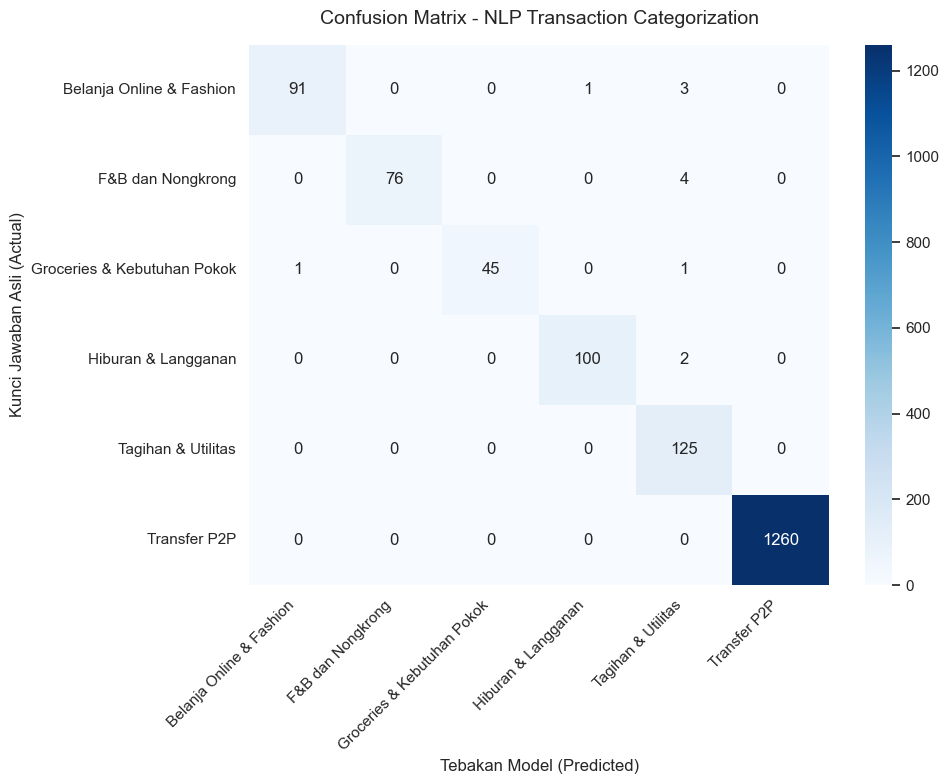

💾 BERHASIL! 'tfidf_vectorizer.pkl' dan 'nlp_model_nb.pkl' telah disimpan dan siap digunakan.


In [11]:
print("⏳ TAHAP 2: Ekstraksi Fitur & Pelatihan Model Naive Bayes...")

# 1. Ekstraksi Fitur dengan TF-IDF (N-Gram 1-2 untuk menangkap frasa)
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X_raw)

print(f"Dimensi matriks TF-IDF: {X_tfidf.shape} (Jumlah data x Jumlah kombinasi kata unik)")

# 2. Train-Test Split (80% Training, 20% Testing)
# 2. Train-Test Split (80% Training, 20% Testing) dengan Stratified
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# 3. Inisialisasi dan Pelatihan Model Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("✅ Model Naive Bayes berhasil dilatih!\n")

print("⏳ TAHAP 3: Evaluasi & Export Pipeline...")

# 4. Prediksi pada data testing
y_pred = nb_model.predict(X_test)

# 5. Evaluasi Metrik (Classification Report)
print("📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# 6. Visualisasi Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
# Mengambil nama label unik yang ada di y_test agar urutan sumbu sesuai
labels = sorted(y_test.unique())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - NLP Transaction Categorization', fontsize=14, pad=15)
plt.xlabel('Tebakan Model (Predicted)', fontsize=12)
plt.ylabel('Kunci Jawaban Asli (Actual)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 7. Export Model & Vectorizer (Pickle)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('nlp_model_nb.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

print("💾 BERHASIL! 'tfidf_vectorizer.pkl' dan 'nlp_model_nb.pkl' telah disimpan dan siap digunakan.")

## 6. Exploratory Data Analysis (EDA)

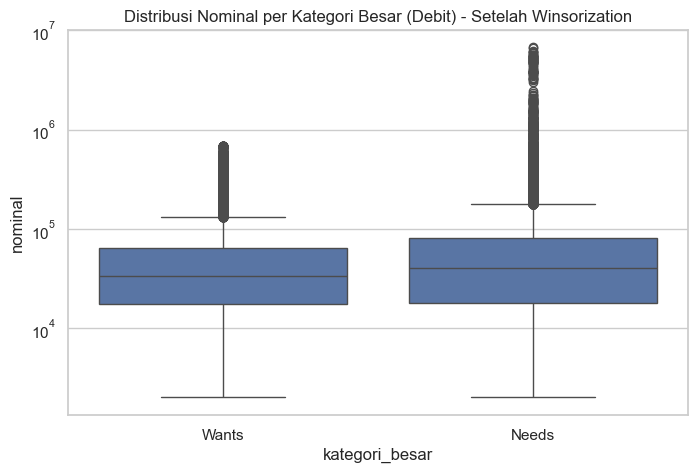

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_transaksi_clean[df_transaksi_clean['tipe_mutasi']=='Debit'], x='kategori_besar', y='nominal')
plt.title('Distribusi Nominal per Kategori Besar (Debit) - Setelah Winsorization')
plt.yscale('log')
plt.show()

## 7. Feature Engineering (Per Nasabah Per Bulan)
Pada langkah ini, transaksi dipecah (*slice*) berdasarkan `id_user` dan `bulan`. Pemecahan bulanan ini sangat penting untuk mendeteksi **dinamika persona** (contoh: nasabah bisa hemat di bulan Januari, tapi sangat boros di bulan Februari). 

Berikut adalah daftar fitur yang diekstrak untuk menangkap profil psikologis dan perilaku nasabah secara komprehensif, guna menajamkan clustering *Tightwad, Unconflicted, Spendthrift*:

| Kelompok | Fitur | Formula / Logika | Alasan (Why) |
|---|---|---|---|
| **Core Ratios** | `wants_ratio` | Total Nominal Wants / Total Nominal Pengeluaran | Pembeda utama persona. Spendthrift > 40%, Tightwad < 20%. |
| **Core Ratios** | `savings_rate` | (Nominal 'Investasi & Finansial' + ΔSaldo Bulanan) / Gaji | Indikator keamanan finansial riil (akumulasi aset + sisa kas). |
| **Core Ratios** | `fixed_costs_ratio` | Total Nominal Needs / Total Nominal Pengeluaran | Tightwad memiliki porsi Needs dominan karena pengeluaran sekunder ditekan. |
| **Habits & Pain** | `wants_frequency` | Jumlah Transaksi Wants / Total Jumlah Transaksi | Mengukur kemudahan tergoda jajan (*Pain of paying* rendah). |
| **Habits & Pain** | `small_leaks_ratio` | Jumlah Transaksi < Rp 30.000 / Total Jumlah Transaksi | Mendeteksi pengeluaran 'bocor halus' yang sering tak disadari Spendthrift. |
| **Temporal** | `night_owl_spending` | Jumlah Transaksi (22:00 - 04:00) / Total Jumlah Transaksi | Transaksi larut malam berkorelasi dengan impulsivitas emosional. |
| **Temporal** | `weekend_surge` | Mean Nominal Weekend / Mean Nominal Weekday | Mengukur lonjakan besaran belanja saat akhir pekan dibandingkan hari kerja. |
| **Temporal** | `early_month_depletion`| Pengeluaran 5 hari pertama setelah gajian / Gaji | Menangkap efek FOMO diskon *Payday Sale* atau buruknya *cashflow management*. |
| **Survival** | `balance_volatility` | Standar Deviasi Saldo Harian / Gaji | Spendthrift memiliki fluktuasi saldo ekstrem karena transaksi tak terduga. |
| **Survival** | `survival_mode_days` | Jumlah Hari di mana Saldo < 15% Gaji | Mengukur seberapa lama nasabah menderita 'tanggal tua'. |


In [13]:
# Filter hanya Debit untuk pengeluaran (kecuali untuk cek saldo)
df_debit = df_transaksi_clean[df_transaksi_clean['tipe_mutasi'] == 'Debit'].copy()

# Merge gaji dari df_nasabah
df_debit = df_debit.merge(df_nasabah[['id_user', 'gaji_bulanan']], on='id_user', how='left')

all_features = []

for uid in df_debit['id_user'].unique():
    u_data = df_debit[df_debit['id_user'] == uid]
    gaji = u_data['gaji_bulanan'].iloc[0]
    u_data_all = df_transaksi_clean[df_transaksi_clean['id_user'] == uid]
    
    # Saldo awal untuk USR ini (saldo sebelum transaksi pertama sama sekali)
    # Kita asumsikan saldo awal adalah sisa_saldo transaksi pertama dikurangi/ditambah nominalnya
    first_row = u_data_all.iloc[0]
    initial_balance = first_row['sisa_saldo'] - first_row['nominal'] if first_row['tipe_mutasi'] == 'Kredit' else first_row['sisa_saldo'] + first_row['nominal']
    
    prev_month_balance = initial_balance
    
    for bulan in sorted(u_data_all['bulan'].unique()):
        m_debit = u_data[u_data['bulan'] == bulan]
        m_all = u_data_all[u_data_all['bulan'] == bulan]
        
        if len(m_all) == 0: continue
            
        total_pengeluaran = m_debit['nominal'].sum()
        total_trx = len(m_debit)
        
        # 1. Core Ratios
        wants_nom = m_debit[m_debit['kategori_besar'] == 'Wants']['nominal'].sum()
        needs_nom = m_debit[m_debit['kategori_besar'] == 'Needs']['nominal'].sum()
        
        wants_ratio = wants_nom / total_pengeluaran if total_pengeluaran > 0 else 0
        fixed_costs_ratio = needs_nom / total_pengeluaran if total_pengeluaran > 0 else 0
        
        # Savings Rate Baru: (Nominal Investasi & Finansial + Perubahan Saldo) / Gaji
        investasi_nom = m_debit[m_debit['kategori_detail'] == 'Investasi & Finansial']['nominal'].sum()
        saldo_akhir = m_all['sisa_saldo'].iloc[-1]
        perubahan_saldo = saldo_akhir - prev_month_balance
        
        savings_total = investasi_nom + perubahan_saldo
        savings_rate = savings_total / gaji if gaji > 0 else 0
        
        # 2. Habits & Pain of Paying
        wants_count = len(m_debit[m_debit['kategori_besar'] == 'Wants'])
        wants_frequency = wants_count / total_trx if total_trx > 0 else 0
        small_leaks_ratio = len(m_debit[m_debit['nominal'] < 30000]) / total_trx if total_trx > 0 else 0
        
        # 3. Temporal
        night_trx = len(m_debit[(m_debit['jam'] >= 22) | (m_debit['jam'] <= 4)])
        night_owl_spending = night_trx / total_trx if total_trx > 0 else 0
        
        # Weekend Surge
        weekend_data = m_debit[m_debit['hari_minggu'] >= 5]
        weekday_data = m_debit[m_debit['hari_minggu'] < 5]
        
        avg_weekend = weekend_data['nominal'].mean() if not weekend_data.empty else 0
        avg_weekday = weekday_data['nominal'].mean() if not weekday_data.empty else 0
        weekend_surge = avg_weekend / avg_weekday if avg_weekday > 0 else (1 if avg_weekend > 0 else 0)
        
        early_days_nom = m_debit[m_debit['hari_bulan'] <= 5]['nominal'].sum()
        early_month_depletion = early_days_nom / gaji if gaji > 0 else 0
        
        # 4. Survival
        daily_balances = m_all.groupby(m_all['timestamp'].dt.date)['sisa_saldo'].last()
        balance_volatility = daily_balances.std() / gaji if len(daily_balances) > 1 and gaji > 0 else 0
        survival_mode_days = (daily_balances < (0.15 * gaji)).sum()
        
        all_features.append({
            'id_user': uid,
            'bulan': bulan,
            'wants_ratio': wants_ratio,
            'fixed_costs_ratio': fixed_costs_ratio,
            'savings_rate': savings_rate,
            'wants_frequency': wants_frequency,
            'small_leaks_ratio': small_leaks_ratio,
            'night_owl_spending': night_owl_spending,
            'weekend_surge': weekend_surge,
            'early_month_depletion': early_month_depletion,
            'balance_volatility': balance_volatility,
            'survival_mode_days': survival_mode_days
        })
        
        # Update balance untuk bulan berikutnya
        prev_month_balance = saldo_akhir

df_features = pd.DataFrame(all_features).fillna(0)
print(f"Feature Engineering selesai. Dihasilkan {len(df_features)} baris fitur (Nasabah x Bulan).")


Feature Engineering selesai. Dihasilkan 1500 baris fitur (Nasabah x Bulan).


## Eksport to CSV

In [14]:
df_transaksi_clean.to_csv("data/Data Transaksi.csv", index=False)
df_features.to_csv('data/Analysis ready.csv', index=False)
print('Data saved successfully')

Data saved successfully
